# Exam Project

Import and set magics:

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display
from fredapi import Fred

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1
from states import REGION

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem 1

### Question 1.1

We download the real GDP and population series from FRED using the API and save the raw data in the data folder.

In [60]:
data_path = 'data'
gdp_path = 'data/gdp_raw.csv'
population_path = 'data/population_raw.csv'
api_key_path = r'C:\Users\GUD\Documents\FRED_API.txt'

if not os.path.isdir(data_path):
    os.mkdir(data_path)

if os.path.isfile(api_key_path):
    with open(api_key_path, 'r') as f:
        fred_api_key = f.read().strip()

    fred = Fred(api_key=fred_api_key)
    gdp_download, population_download = Problem1.download_state_data(fred)

    gdp_download.to_csv(gdp_path)
    population_download.to_csv(population_path)

gdp_raw = pd.read_csv(gdp_path, index_col='year')
population_raw = pd.read_csv(population_path, index_col='year')

We keep the years that match in the two datasets. We then drop states with missing observations and calculate real GDP per person for the states we keep.

In [61]:
gdp, population = Problem1.clean_state_data(gdp_raw, population_raw)
y = 1000 * gdp / population

t_first = int(y.index[0])
t_last = int(y.index[-1])

print(f'Years kept: {t_first}-{t_last} ({len(y.index)} years)')
print(f'States kept: {len(y.columns)}')


Years kept: 1997-2025 (29 years)
States kept: 50


The following table shows the highest and lowest state, their ratio, and the average across states in the first and last year.

In [62]:
summary = Problem1.endpoint_summary(y, [t_first, t_last])
display(summary.round(2))

,highest state,highest,lowest state,lowest,highest / lowest,average
year,,,,,,
1997,DE,69748.74,ID,32062.68,2.18,44592.95
2025,NY,94701.99,MS,42434.03,2.23,64674.46


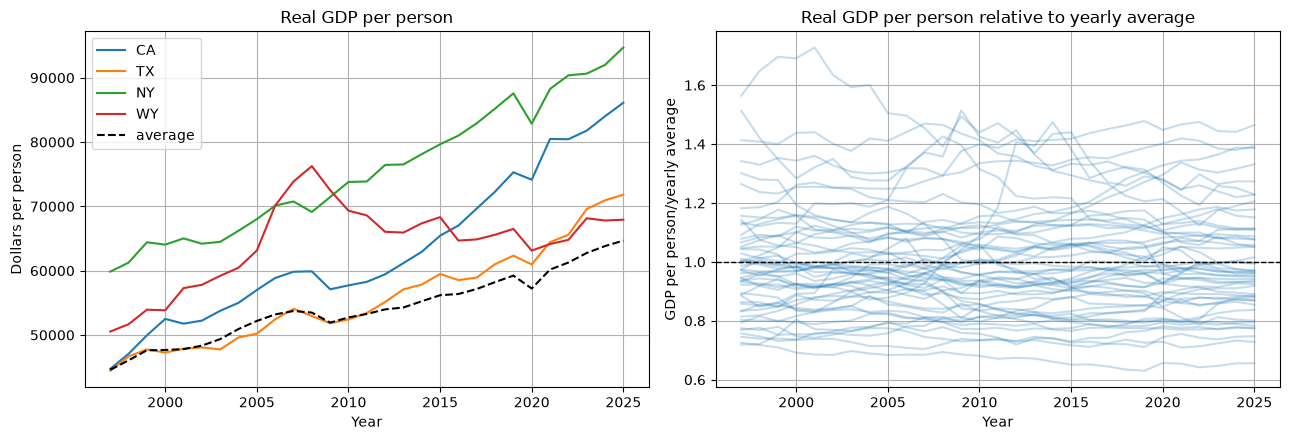

In [63]:
y_avg = y.mean(axis=1)
relative_y = y.div(y_avg, axis=0)

plot_states = ['CA', 'TX', 'NY', 'WY']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for state in plot_states:
    axes[0].plot(y.index, y[state], label=state)
axes[0].plot(y.index, y_avg, 'k--', label='average')
axes[0].set_title('Real GDP per person')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Dollars per person')
axes[0].legend()
axes[0].grid(True)

for state in relative_y.columns:
    axes[1].plot(relative_y.index, relative_y[state], color='C0', alpha=0.25)
axes[1].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Real GDP per person relative to yearly average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP per person/yearly average')
axes[1].grid(True)

fig.tight_layout()

The first figure shows the real GDP per person for four states and the average across states. The second figure shows every states GDP per person relative to the average of all states.

### Question 1.2

For every year, we measure how much log(y_i,t) differs between states by calculating the standard deviation.

Standard deviation in 1997: 0.1814
Standard deviation in 2025: 0.1768
Maximum: 2012 (0.1890)
Minimum: 2005 (0.1666)


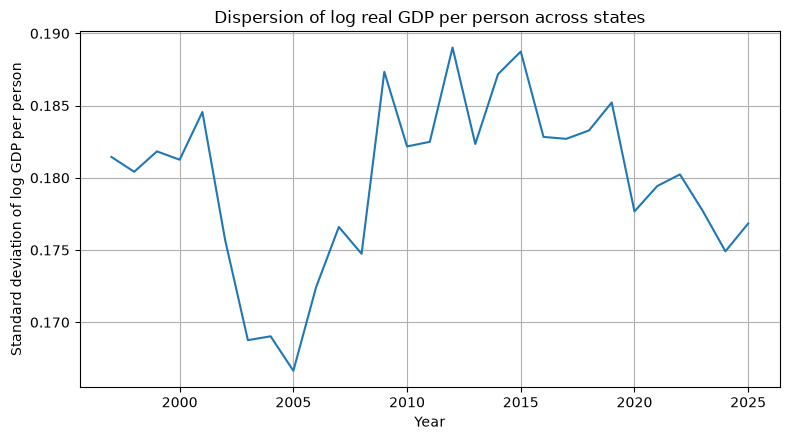

In [64]:
std_log_y = np.log(y).std(axis=1, ddof=0)

max_year = std_log_y.idxmax()
min_year = std_log_y.idxmin()

print(f'Standard deviation in {t_first}: {std_log_y.loc[t_first]:.4f}')
print(f'Standard deviation in {t_last}: {std_log_y.loc[t_last]:.4f}')
print(f'Maximum: {max_year} ({std_log_y.loc[max_year]:.4f})')
print(f'Minimum: {min_year} ({std_log_y.loc[min_year]:.4f})')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(std_log_y.index, std_log_y)
ax.set_title('Dispersion of log real GDP per person across states')
ax.set_xlabel('Year')
ax.set_ylabel('Standard deviation of log GDP per person')
ax.grid(True)
fig.tight_layout()

From the figure we can conclude that there is no clear trend.

### Question 1.3

For every state we calculate average annual growth as the change in log real GDP per person divided by the number of years. We then estimate g_i = a + b log(y_i,t_first).

In [65]:
T = t_last - t_first
log_y_first = np.log(y.loc[t_first])
g = (np.log(y.loc[t_last]) - log_y_first) / T

b, a = np.polyfit(log_y_first, g, 1)
corr = np.corrcoef(log_y_first, g)[0, 1]
lambda_ = -np.log(1 + b * T) / T
half_life = np.log(2) / lambda_

high_states = g.sort_values(ascending=False).head(5).index
low_states = g.sort_values().head(5).index

print(f'a = {a:.6f}')
print(f'b = {b:.6f}')
print(f'Correlation = {corr:.4f}')
print(f'lambda = {lambda_:.6f} per year')
print(f'Half-life = {half_life:.2f} years')

a = 0.118089
b = -0.009802
Correlation = -0.3886
lambda = 0.011459 per year
Half-life = 60.49 years


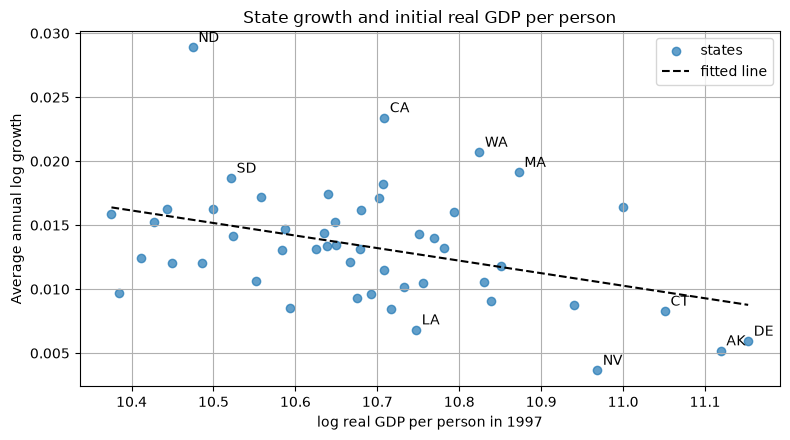

In [66]:
x_fit = np.linspace(log_y_first.min(), log_y_first.max(), 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(log_y_first, g, alpha=0.7, label='states')
ax.plot(x_fit, a + b * x_fit, 'k--', label='fitted line')

for state in list(high_states) + list(low_states):
    ax.annotate(
        state,
        (log_y_first[state], g[state]),
        xytext=(4, 4),
        textcoords='offset points'
    )

ax.set_title('State growth and initial real GDP per person')
ax.set_xlabel(f'log real GDP per person in {t_first}')
ax.set_ylabel('Average annual log growth')
ax.legend()
ax.grid(True)
fig.tight_layout()

The estimated slope is negative, which shows convergence as states with lower initial real GDP per person tend to grow faster. It should be noted though that the correalation between GDP per person and growth is not that high.

### Question 1.4


First we compare GDP per person for each state with the average across all states in that year. We then take the average of the relative values for each region.

Number of states in each region:


,number of states
Northeast,9
Midwest,12
South,16
West,13


Regional relative GDP per person:


,1997,2025,change
Northeast,1.0873,1.0952,0.0079
Midwest,0.9683,1.0055,0.0372
South,0.9513,0.9054,-0.0459
West,1.0287,1.0454,0.0167


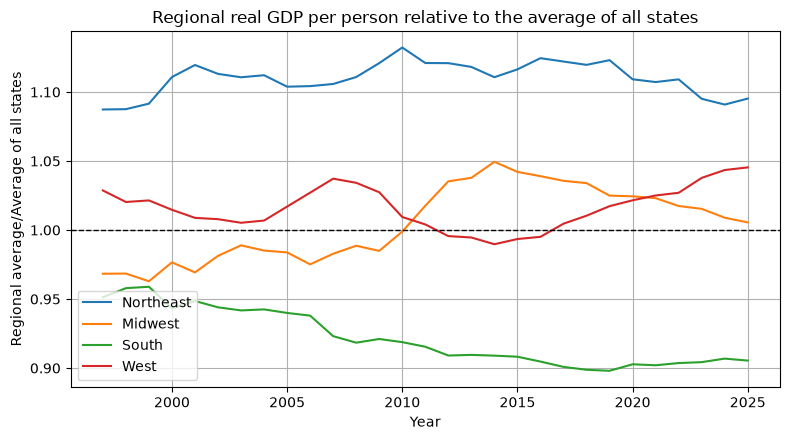

In [67]:
regions = pd.Series({state: REGION[state] for state in y.columns})
region_rel = relative_y.T.groupby(regions).mean().T
region_rel = region_rel[['Northeast', 'Midwest', 'South', 'West']]

region_counts = regions.value_counts().reindex(region_rel.columns)
region_summary = pd.DataFrame({
    t_first: region_rel.loc[t_first],
    t_last: region_rel.loc[t_last],
})
region_summary['change'] = region_summary[t_last] - region_summary[t_first]

print('Number of states in each region:')
display(region_counts.to_frame('number of states'))
print('Regional relative GDP per person:')
display(region_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
for region in region_rel.columns:
    ax.plot(region_rel.index, region_rel[region], label=region)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Regional real GDP per person relative to the average of all states')
ax.set_xlabel('Year')
ax.set_ylabel('Regional average/Average of all states')
ax.legend()
ax.grid(True)
fig.tight_layout()

The South has the largest change and moves downward relative to the average of all the states. The Midwest has the largest positive change.